In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Cleaned_Insurance_data (1).csv to Cleaned_Insurance_data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('Cleaned_Insurance_data (1).csv')

In [ ]:
df['bloodpressure'].describe()

,bloodpressure
count,2058.000000
mean,69.999028
std,19.661155
min,0.000000
25%,64.000000
50%,72.000000
75%,80.000000
max,122.000000


In [ ]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,82,1,0,HomeMakers,1731.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  2058 non-null   float64
 1   sex                  2058 non-null   object 
 2   weight               2058 non-null   int64  
 3   bmi                  2058 non-null   float64
 4   hereditary_diseases  2058 non-null   object 
 5   no_of_dependents     2058 non-null   int64  
 6   smoker               2058 non-null   int64  
 7   bloodpressure        2058 non-null   int64  
 8   diabetes             2058 non-null   int64  
 9   regular_ex           2058 non-null   int64  
 10  job_title            2058 non-null   object 
 11  claim                2058 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 193.1+ KB


### **Feature Engineering & Encoding**

In [ ]:
# Feature Engineering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])




In [ ]:
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,1,64,24.3,NoDisease,1,0,72,0,0,Actor,13112.6
1,49.0,0,75,22.6,NoDisease,1,0,78,1,1,Engineer,9567.0
2,32.0,0,64,17.8,Epilepsy,2,1,88,1,1,Academician,32734.2
3,61.0,0,53,36.4,NoDisease,1,1,72,1,0,Chef,48517.6
4,19.0,0,50,20.6,NoDisease,0,0,82,1,0,HomeMakers,1731.7


In [ ]:
# One Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        'hereditary_diseases',
        'job_title'
    ],
    drop_first=True,
    dtype=int
)

In [ ]:
df.head()

,age,sex,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,...,job_title_Journalist,job_title_Labourer,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician
0,60.0,1,64,24.3,1,0,72,0,0,13112.6,...,0,0,0,0,0,0,0,0,0,0
1,49.0,0,75,22.6,1,0,78,1,1,9567.0,...,0,0,0,0,0,0,0,0,0,0
2,32.0,0,64,17.8,2,1,88,1,1,32734.2,...,0,0,0,0,0,0,0,0,0,0
3,61.0,0,53,36.4,1,1,72,1,0,48517.6,...,0,0,0,0,0,0,0,0,0,0
4,19.0,0,50,20.6,0,0,82,1,0,1731.7,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(2058, 53)

In [ ]:
df.to_csv(
    "encoded_insurance.csv",
    index=False
)

### Separate Features and Target

In [ ]:
X = df.drop('claim', axis=1)

y = df['claim']

In [ ]:
print(X.shape)
print(y.shape)

(2058, 52)
(2058,)


### Feature Scaling

In [ ]:
num_cols = [
    'age',
    'weight',
    'bmi',
    'bloodpressure'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
X.head()

,age,sex,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,hereditary_diseases_Arthritis,...,job_title_Journalist,job_title_Labourer,job_title_Lawyer,job_title_Manager,job_title_Photographer,job_title_Police,job_title_Politician,job_title_Singer,job_title_Student,job_title_Technician
0,1.641863,1,-0.065545,-0.954854,1,0,0.101798,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.808713,0,0.779926,-1.258467,1,0,0.407042,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.478883,0,-0.065545,-2.115728,2,1,0.915783,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1.717604,0,-0.911015,1.206156,1,1,0.101798,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-1.463515,0,-1.141598,-1.615659,0,0,0.610538,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# save Scaler
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


###  Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (1646, 52)
Testing Shape : (412, 52)


### Modal Training

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [ ]:
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

0.6230128926142537
0.5606625018255244


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.907729346946185
0.6597908895719332


In [ ]:
# XGBOOST
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


In [ ]:
print(xgb.score(X_train, y_train))
print(xgb.score(X_test, y_test))

0.9829892643186839
0.6700719405826503


### Evaluation Matrix

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
def evaluate_model(y_true, pred, model_name):

    mae = mean_absolute_error(y_true, pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(y_true, pred)

    print("\n", "="*50)
    print(model_name)
    print("="*50)

    print("MAE :", round(mae,2))
    print("RMSE :", round(rmse,2))
    print("R2 Score :", round(r2,4))

    return [model_name, mae, rmse, r2]

### Evaluate All Models

In [ ]:
#Linear Regression
lr_result = evaluate_model(
    y_test,
    lr_pred,
    "Linear Regression"
)
# Random Forest
rf_result = evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)
# XGboost
xgb_result = evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)


Linear Regression
MAE : 5792.15
RMSE : 7774.91
R2 Score : 0.5607

Random Forest
MAE : 4614.22
RMSE : 6841.78
R2 Score : 0.6598

XGBoost
MAE : 4730.54
RMSE : 6737.61
R2 Score : 0.6701


In [ ]:
# Model Comparision
results = pd.DataFrame(
    [
        lr_result,
        rf_result,
        xgb_result
    ],
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print(results)

               Model          MAE         RMSE        R2
0  Linear Regression  5792.148703  7774.912781  0.560663
1      Random Forest  4614.223521  6841.784002  0.659791
2            XGBoost  4730.544326  6737.612283  0.670072


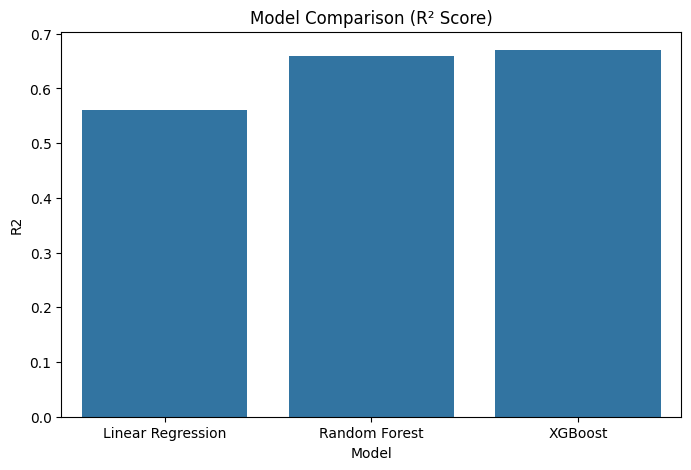

In [ ]:
# Visual comparision

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison (R² Score)")
plt.show()

In [ ]:
best_model = xgb

In [ ]:
# import joblib

joblib.dump(
    best_model,
    "claim_prediction_model.pkl"
)

['claim_prediction_model.pkl']

### Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                             Feature  Importance
5                             smoker    0.272331
16     hereditary_diseases_NoDisease    0.107720
7                           diabetes    0.046402
17       hereditary_diseases_Obesity    0.031824
11      hereditary_diseases_Diabetes    0.029843
9      hereditary_diseases_Arthritis    0.028615
33                job_title_Engineer    0.028383
10        hereditary_diseases_Cancer    0.024774
14  hereditary_diseases_HeartDisease    0.024274
38             job_title_GovEmployee    0.020966
8                         regular_ex    0.017454
13    hereditary_diseases_EyeDisease    0.016627
32                  job_title_Doctor    0.016384
12      hereditary_diseases_Epilepsy    0.015578
3                                bmi    0.014757


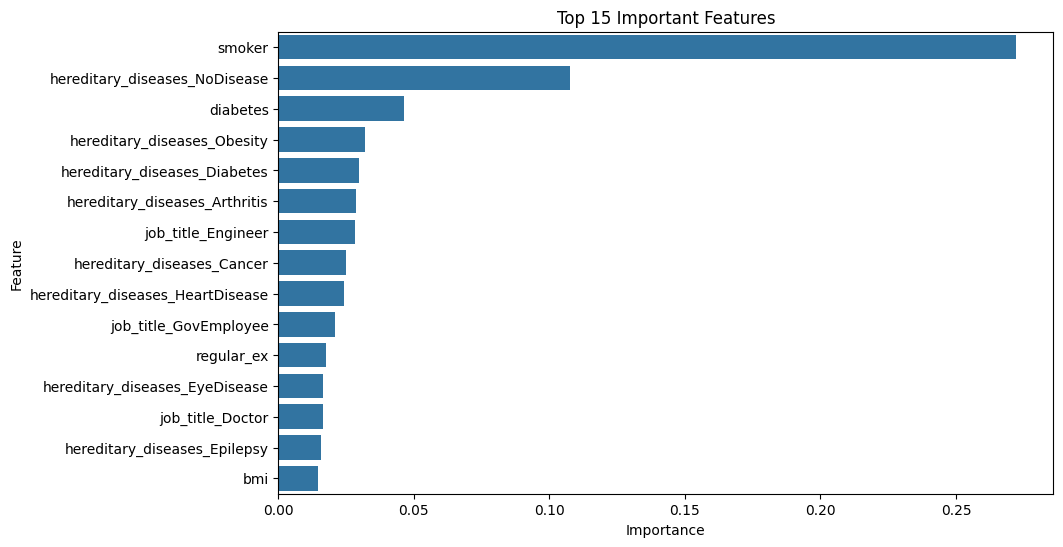

In [ ]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

### Risk Score Generation

In [ ]:
risk_df = df.copy()

In [ ]:
# BMI Risk
risk_df["bmi_score"] = 0

risk_df.loc[risk_df["bmi"] >= 30, "bmi_score"] = 3
risk_df.loc[(risk_df["bmi"] >= 25) &
            (risk_df["bmi"] < 30), "bmi_score"] = 2
risk_df.loc[(risk_df["bmi"] >= 18.5) &
            (risk_df["bmi"] < 25), "bmi_score"] = 1


In [ ]:
# Smoking Risk
risk_df["smoker_score"] = risk_df["smoker"] * 4

In [ ]:
# Diabetes Risk
risk_df["diabetes_score"] = risk_df["diabetes"] * 3

In [ ]:
#Blood Pressure Risk
risk_df["bp_score"] = 0

# Low Risk
risk_df.loc[
    risk_df["bloodpressure"] < 64,
    "bp_score"
] = 1

# Medium Risk
risk_df.loc[
    (risk_df["bloodpressure"] >= 64) &
    (risk_df["bloodpressure"] < 80),
    "bp_score"
] = 2

# High Risk
risk_df.loc[
    risk_df["bloodpressure"] >= 80,
    "bp_score"
] = 3

In [ ]:
# Claim Risk
claim_q1 = risk_df["claim"].quantile(0.33)
claim_q2 = risk_df["claim"].quantile(0.66)

risk_df["claim_score"] = 1

risk_df.loc[
    risk_df["claim"] > claim_q1,
    "claim_score"
] = 2

risk_df.loc[
    risk_df["claim"] > claim_q2,
    "claim_score"
] = 3

In [ ]:
#Final Risk Score
risk_df["risk_score"] = (
      risk_df["bmi_score"]
    + risk_df["smoker_score"]
    + risk_df["diabetes_score"]
    + risk_df["bp_score"]
    + risk_df["claim_score"]
)

In [ ]:
print(
    risk_df["risk_score"].describe()
)

count    2058.000000
mean        9.420797
std         3.126843
min         3.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        16.000000
Name: risk_score, dtype: float64


### Create Risk Categories

In [ ]:
low_cutoff = risk_df["risk_score"].quantile(0.33)

high_cutoff = risk_df["risk_score"].quantile(0.66)

In [ ]:
def risk_category(score):

    if score <= low_cutoff:
        return "Low Risk"

    elif score <= high_cutoff:
        return "Medium Risk"

    else:
        return "High Risk"

In [ ]:
risk_df["risk_category"] = (
    risk_df["risk_score"]
    .apply(risk_category)
)

In [ ]:
# Number of Risk Category
print(
    risk_df["risk_category"]
    .value_counts()
)

risk_category
Low Risk       844
High Risk      678
Medium Risk    536
Name: count, dtype: int64


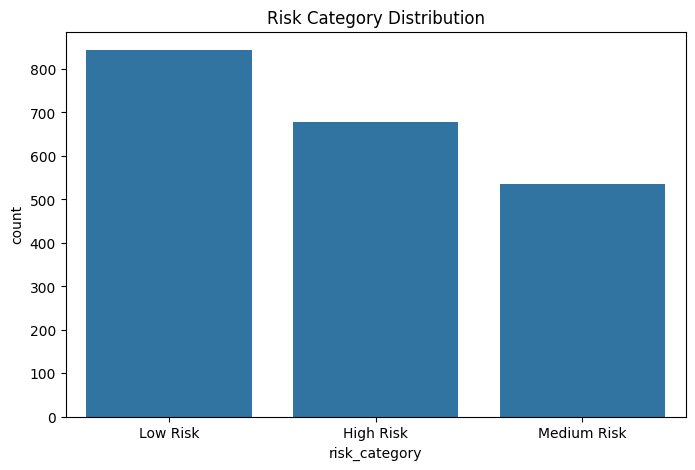

In [ ]:
# Visualization of Risk Category
plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_df,
    x="risk_category"
)

plt.title("Risk Category Distribution")

plt.show()

### Average Claim by Risk Level

In [ ]:
risk_df.groupby(
    "risk_category"
)["claim"].mean()

,claim
risk_category,
High Risk,27973.992035
Low Risk,8855.742417
Medium Risk,11771.602239


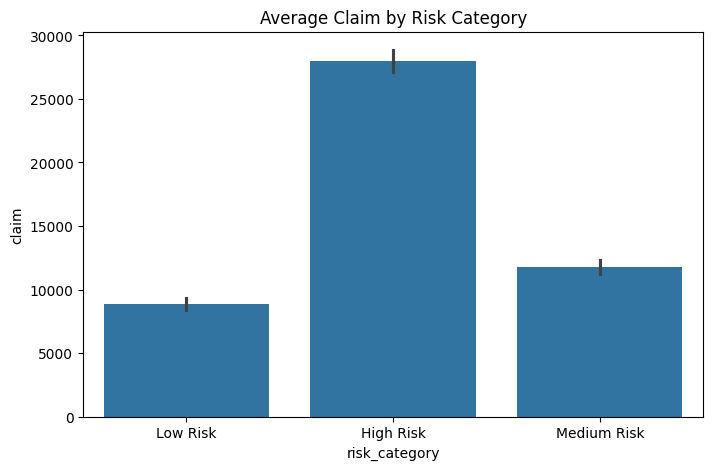

In [ ]:
# Visualization
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_df,
    x="risk_category",
    y="claim"
)

plt.title(
    "Average Claim by Risk Category"
)

plt.show()

In [ ]:
risk_df.to_csv(
    "insurance_with_risk.csv",
    index=False
)

In [ ]:
risk_df.head()

,age,sex,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim,...,job_title_Singer,job_title_Student,job_title_Technician,bmi_score,smoker_score,diabetes_score,bp_score,claim_score,risk_score,risk_category
0,60.0,1,64,24.3,1,0,72,0,0,13112.6,...,0,0,0,1,0,0,2,2,5,Low Risk
1,49.0,0,75,22.6,1,0,78,1,1,9567.0,...,0,0,0,1,0,3,2,2,8,Low Risk
2,32.0,0,64,17.8,2,1,88,1,1,32734.2,...,0,0,0,0,4,3,3,3,13,High Risk
3,61.0,0,53,36.4,1,1,72,1,0,48517.6,...,0,0,0,3,4,3,2,3,15,High Risk
4,19.0,0,50,20.6,0,0,82,1,0,1731.7,...,0,0,0,1,0,3,3,1,8,Low Risk


### Customer Segmentation Using K-Means

In [ ]:
cluster_features = [
    "risk_score",
    "claim",
    "age",
    "no_of_dependents"
]

In [ ]:
# Create Clustering Dataset
cluster_df = risk_df[cluster_features].copy()

In [ ]:
# K-means is distance - based
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_df
)

In [ ]:
# Determine the optimal number of clusters
from sklearn.cluster import KMeans


wcss = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    wcss.append(
        kmeans.inertia_
    )

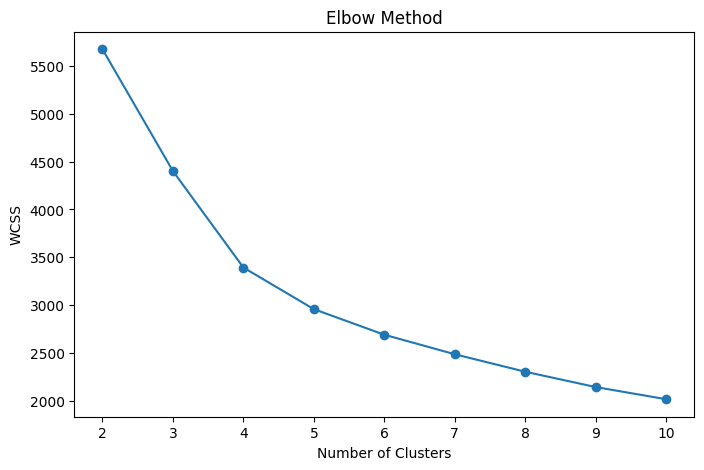

In [ ]:
# Visualize Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
# Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_scaled
    )

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    print(
        f"K={k}  Silhouette={score:.4f}"
    )

K=2  Silhouette=0.3074
K=3  Silhouette=0.2731
K=4  Silhouette=0.3112
K=5  Silhouette=0.3032
K=6  Silhouette=0.2927
K=7  Silhouette=0.2629
K=8  Silhouette=0.2634
K=9  Silhouette=0.2596
K=10  Silhouette=0.2639


In [ ]:
# Train Final K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

risk_df["cluster"] = (
    kmeans.fit_predict(
        cluster_scaled
    )
)

In [ ]:
# Cluster Distribution
print(
    risk_df["cluster"]
    .value_counts()
)

cluster
0    627
1    495
2    469
3    467
Name: count, dtype: int64


In [ ]:
# analysis of cluster
cluster_summary = risk_df.groupby(
    "cluster"
)[
   [
    "risk_score",
    "claim",
    "age"

]
].mean()

print(cluster_summary)

         risk_score         claim        age
cluster                                     
0          7.531100   7368.387560  26.156300
1          8.694949  13936.409697  52.351515
2          8.437100  12179.276333  40.204691
3         13.715203  33232.568737  37.897216


In [ ]:
# Naming the cluster
cluster_names = {
    0:"Healthy Low-Risk",
    1:"High-Risk Customers",
    2:"Moderate Risk",
    3:"Premium Customers"
}

In [ ]:
risk_df["customer_segment"] = (
    risk_df["cluster"]
    .map(cluster_names)
)

In [ ]:
# verification
print(
    risk_df["customer_segment"]
    .value_counts()
)

customer_segment
Healthy Low-Risk       627
High-Risk Customers    495
Moderate Risk          469
Premium Customers      467
Name: count, dtype: int64


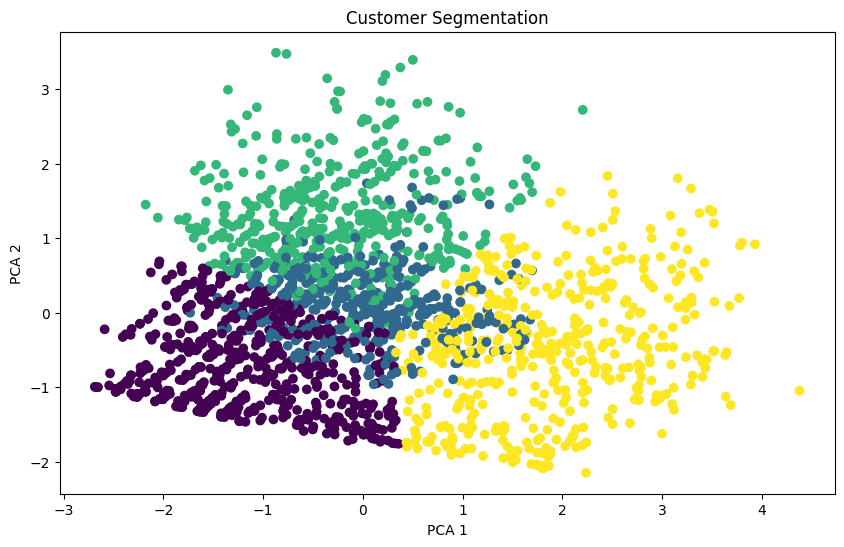

In [ ]:
# 2D Cluster Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(
    cluster_scaled
)
plt.figure(figsize=(10,6))

plt.scatter(
    cluster_pca[:,0],
    cluster_pca[:,1],
    c=risk_df["cluster"]
)

plt.title(
    "Customer Segmentation"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [ ]:
# Average claim by segment
risk_df.groupby(
    "customer_segment"
)["claim"].mean()

,claim
customer_segment,
Healthy Low-Risk,7368.387560
High-Risk Customers,13936.409697
Moderate Risk,12179.276333
Premium Customers,33232.568737


In [ ]:
# Avreage risk score
risk_df.groupby(
    "customer_segment"
)["risk_score"].mean()

,risk_score
customer_segment,
Healthy Low-Risk,7.531100
High-Risk Customers,8.694949
Moderate Risk,8.437100
Premium Customers,13.715203


### Save KMeans Model

In [ ]:
import joblib

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    cluster_scaler,
    "cluster_scaler.pkl"
)

['cluster_scaler.pkl']

In [ ]:
# Save Updated Dataset
risk_df.to_csv(
    "insurance_final.csv",
    index=False
)

### Premium Recommendation Engine

In [ ]:
# Create Predicted Claim Column
risk_df["predicted_claim"] = best_model.predict(X)

In [ ]:
risk_df[
    ["claim","predicted_claim"]
].head()

,claim,predicted_claim
0,13112.6,14869.595703
1,9567.0,9725.006836
2,32734.2,32676.984375
3,48517.6,49362.457031
4,1731.7,2744.265381


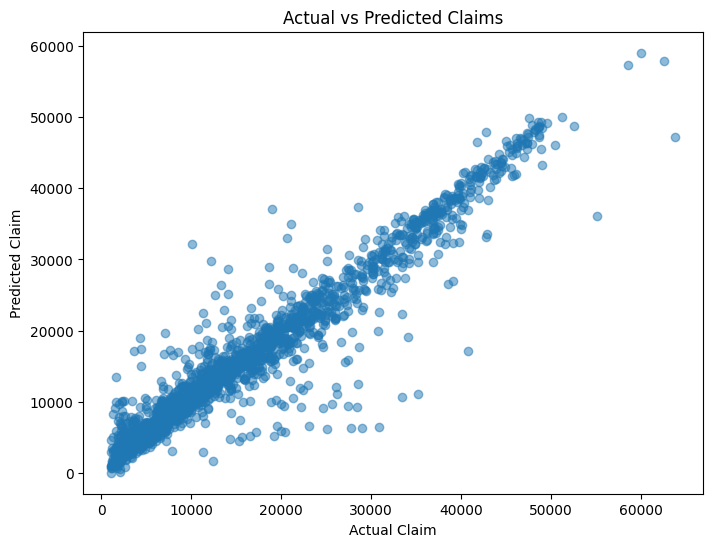

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    risk_df["claim"],
    risk_df["predicted_claim"],
    alpha=0.5
)

plt.xlabel("Actual Claim")
plt.ylabel("Predicted Claim")
plt.title("Actual vs Predicted Claims")

plt.show()

#### Define Business Parameters

In [ ]:
average_claim = risk_df["claim"].mean()

print(average_claim * 0.4)

6365.440621963071


In [ ]:
BASE_PREMIUM = risk_df["claim"].quantile(0.25)
print(BASE_PREMIUM)

6600.25


In [ ]:
BASE_PREMIUM  = 6600
PROFIT_MARGIN = 0.20

In [ ]:
# Risk Loading
risk_df["risk_loading"] = (
    risk_df["risk_score"] * 500
)


### Calculate Premium

In [ ]:
# Calculate Premium
risk_df["recommended_premium"] = (

    BASE_PREMIUM

    + risk_df["risk_loading"]

    + risk_df["predicted_claim"]

)

In [ ]:
# Add Profit Margin
risk_df["recommended_premium"] = (

    risk_df["recommended_premium"]

    * (1 + PROFIT_MARGIN)

)

In [ ]:
# check
risk_df[
[
"risk_score",
"predicted_claim",
"recommended_premium"
]
].head()

,risk_score,predicted_claim,recommended_premium
0,5,14869.595703,28763.514844
1,8,9725.006836,24390.008203
2,13,32676.984375,54932.381250
3,15,49362.457031,76154.948438
4,8,2744.265381,16013.118457


### Premium Distribution

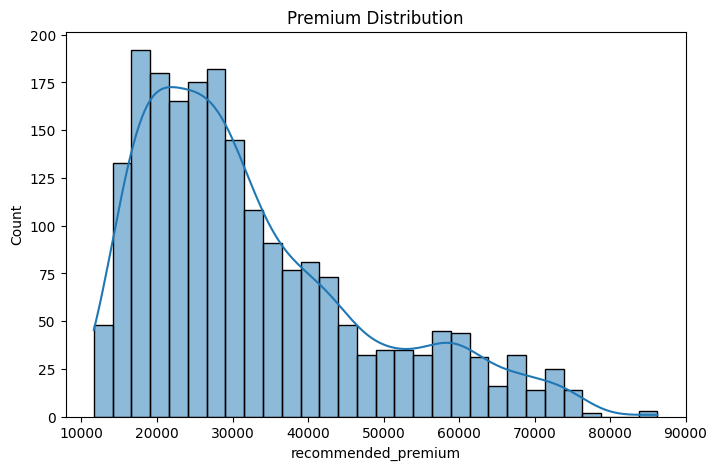

In [ ]:
# Premium Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    risk_df["recommended_premium"],
    bins=30,
    kde=True
)

plt.title(
    "Premium Distribution"
)

plt.show()



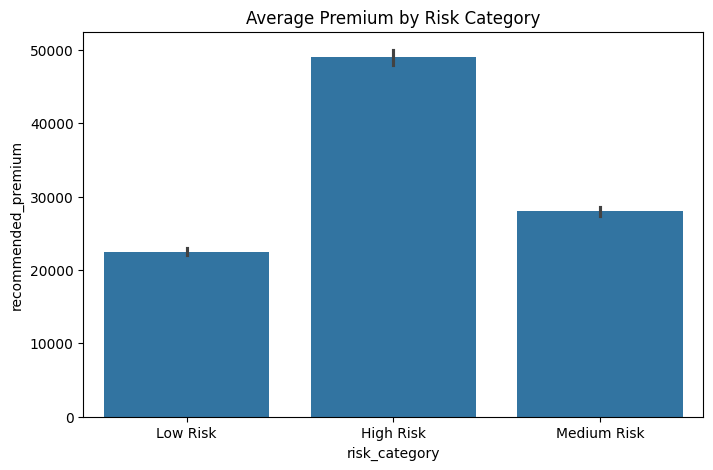

In [ ]:
# Premium by Risk Category
risk_df.groupby(
    "risk_category"
)["recommended_premium"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_df,
    x="risk_category",
    y="recommended_premium"
)

plt.title(
    "Average Premium by Risk Category"
)

plt.show()

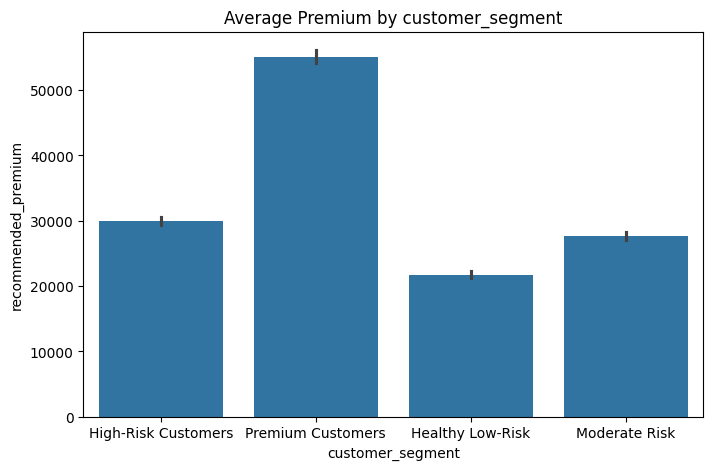

In [ ]:
# Premium by Customer Segment
risk_df.groupby(
    "customer_segment"
)["recommended_premium"].mean()
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_df,
    x=  "customer_segment",
    y="recommended_premium"
)

plt.title(
    "Average Premium by customer_segment"
)

plt.show()


In [ ]:
risk_df.to_csv(
    "insurance_premium_output.csv",
    index=False
)

In [ ]:
# Creating SHAP Explainer
import shap

explainer = shap.TreeExplainer(best_model)

In [ ]:
# Calculate SHAP Values
shap_values = explainer.shap_values(X_test)

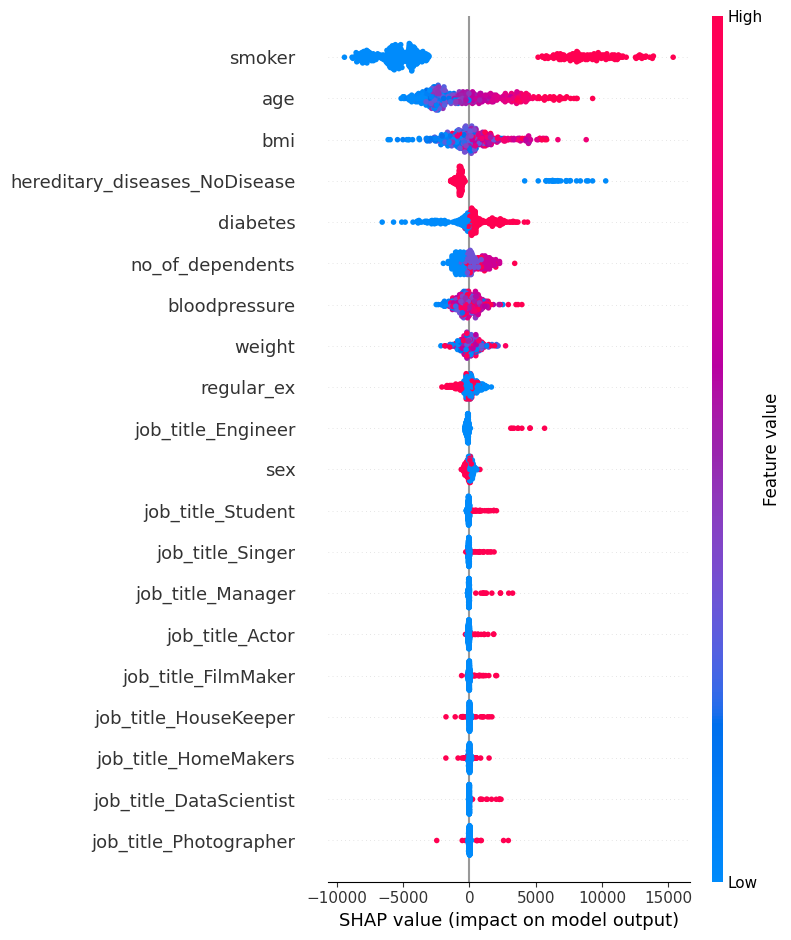

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

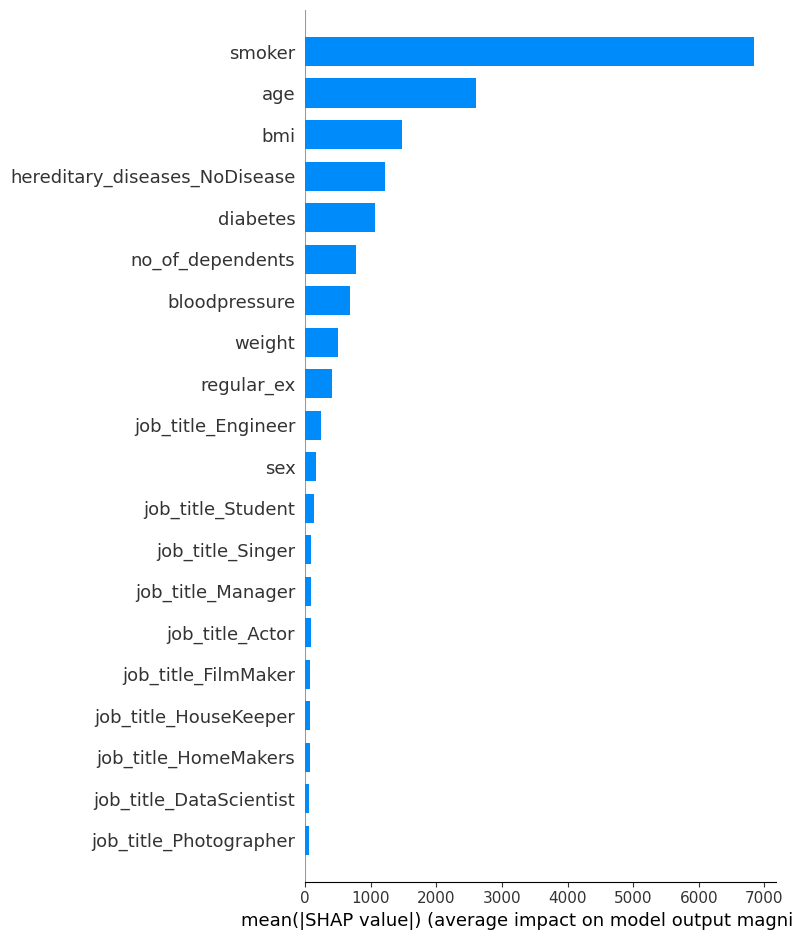

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

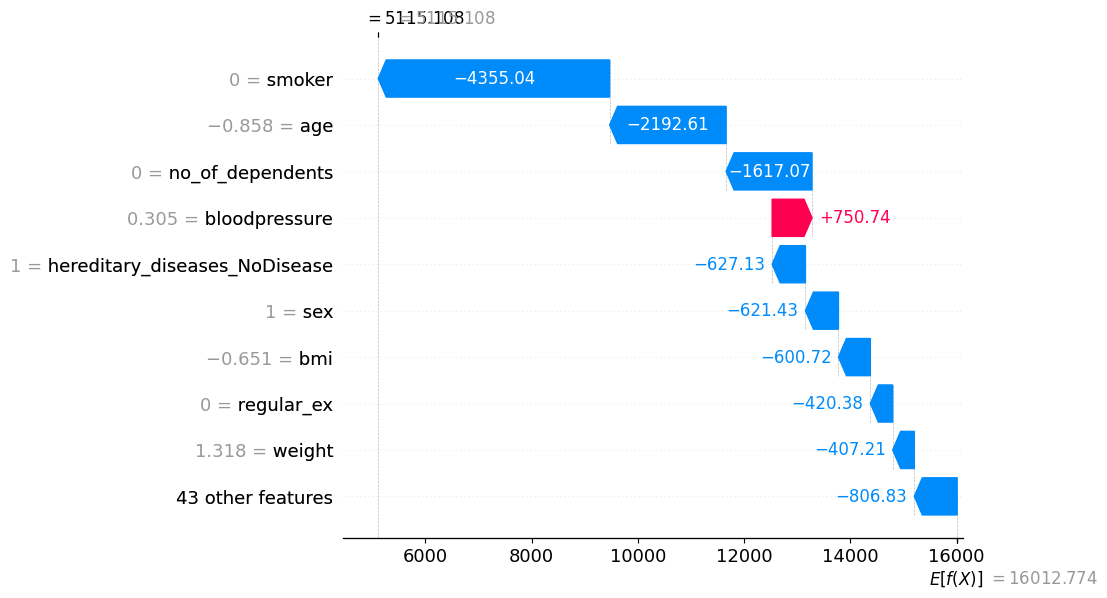

In [ ]:
# Individual Customer Explanation
customer_index = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer_index],
        feature_names=X_test.columns
    )
)

In [ ]:
# Explain Premium
customer = risk_df.iloc[0]

print("Risk Category:", customer["risk_category"])

print("Risk Score:", customer["risk_score"])

print("Predicted Claim:", customer["predicted_claim"])

print("Recommended Premium:",
      customer["recommended_premium"])

Risk Category: Low Risk
Risk Score: 5
Predicted Claim: 14869.596
Recommended Premium: 28763.51484375


In [ ]:
# Save SHAP Explainer
import joblib

joblib.dump(
    explainer,
    "shap_explainer.pkl"
)

['shap_explainer.pkl']

### Feature Importance DataFrame

In [ ]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
    np.abs(shap_values).mean(axis=0)

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                          Feature   Importance
5                          smoker  6837.467285
0                             age  2610.559570
3                             bmi  1474.696045
16  hereditary_diseases_NoDisease  1210.871582
7                        diabetes  1072.438965
4                no_of_dependents   779.059692
6                   bloodpressure   680.633789
2                          weight   507.179169
8                      regular_ex   411.996368
33             job_title_Engineer   242.125473
1                             sex   167.089188
50              job_title_Student   130.119125
49               job_title_Singer    92.624840
45              job_title_Manager    91.957191
19                job_title_Actor    82.542938
37            job_title_FilmMaker    77.824074
40          job_title_HouseKeeper    72.920990
39           job_title_HomeMakers    68.409622
30        job_title_DataScientist    63.013206
46         job_title_Photographer    55.772751


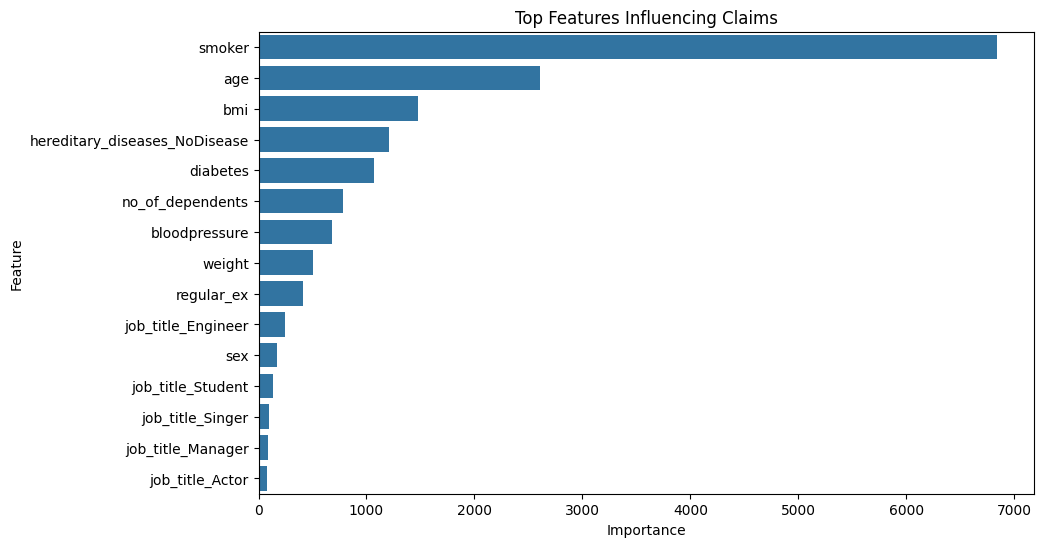

In [ ]:
# Visualization for Report
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing Claims"
)

plt.show()

### Risk Classification Model

In [ ]:
# Create Classification Dataset
risk_features = risk_df[X_train.columns]

risk_target = risk_df["risk_category"]

In [ ]:
print(risk_features.shape)
print(risk_target.shape)

(2058, 52)
(2058,)


In [ ]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

risk_label_encoder = LabelEncoder()

risk_target_encoded = (
    risk_label_encoder.fit_transform(
        risk_target
    )
)

for i, label in enumerate(
    risk_label_encoder.classes_
):
    print(i, label)

0 High Risk
1 Low Risk
2 Medium Risk


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train_risk, X_test_risk, y_train_risk, y_test_risk = (
    train_test_split(
        risk_features,
        risk_target_encoded,
        test_size=0.20,
        random_state=42,
        stratify=risk_target_encoded
    )
)

In [ ]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier

rf_risk_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_risk_model.fit(
    X_train_risk,
    y_train_risk
)

rf_risk_pred = rf_risk_model.predict(
    X_test_risk
)

In [ ]:
# XGBOOST CLASSIFIER

from xgboost import XGBClassifier

xgb_risk_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_risk_model.fit(
    X_train_risk,
    y_train_risk
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Prediction
xgb_risk_pred = xgb_risk_model.predict(
    X_test_risk
)

In [ ]:
# Evaluate Random Forest
from sklearn.metrics import (
    accuracy_score,
    classification_report
)
print(
    "Accuracy:",
    accuracy_score(
        y_test_risk,
        rf_risk_pred
    )
)

print(
    classification_report(
        y_test_risk,
        rf_risk_pred
    )
)


Accuracy: 0.8470873786407767
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       136
           1       0.91      0.93      0.92       169
           2       0.74      0.64      0.69       107

    accuracy                           0.85       412
   macro avg       0.83      0.83      0.83       412
weighted avg       0.84      0.85      0.84       412



In [ ]:
# Evaluate XGBoost

print(
    "Accuracy:",
    accuracy_score(
        y_test_risk,
        xgb_risk_pred
    )
)

print(
    classification_report(
        y_test_risk,
        xgb_risk_pred
    )
)

Accuracy: 0.8883495145631068
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       136
           1       0.93      0.96      0.94       169
           2       0.79      0.79      0.79       107

    accuracy                           0.89       412
   macro avg       0.88      0.88      0.88       412
weighted avg       0.89      0.89      0.89       412



In [ ]:
# Confusion Matrix

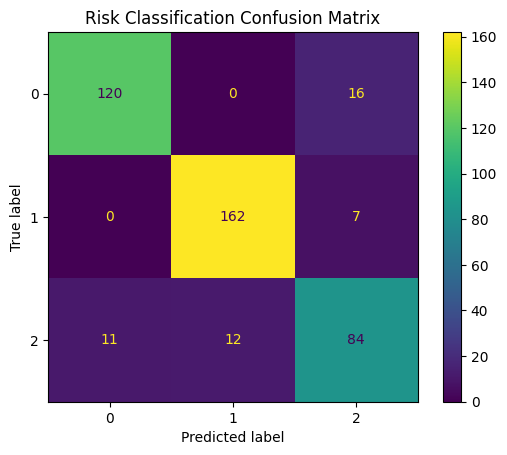

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_risk,
    xgb_risk_pred
)
plt.title("Risk Classification Confusion Matrix")
plt.show()


Top 15 Important Features
                          Feature  Importance
5                          smoker    0.444392
7                        diabetes    0.146467
17    hereditary_diseases_Obesity    0.056432
3                             bmi    0.025619
6                   bloodpressure    0.024861
12   hereditary_diseases_Epilepsy    0.023100
16  hereditary_diseases_NoDisease    0.022827
25                   job_title_CA    0.022340
0                             age    0.020631
49               job_title_Singer    0.014843
18           job_title_Accountant    0.013291
37            job_title_FilmMaker    0.012336
43             job_title_Labourer    0.011518
50              job_title_Student    0.011122
10     hereditary_diseases_Cancer    0.010751


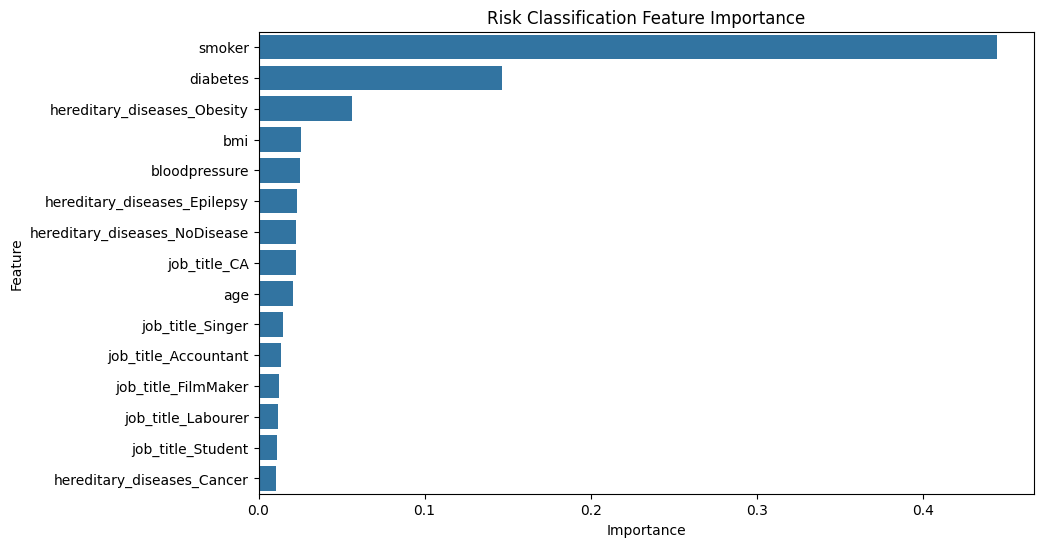

In [ ]:
# Feature Importance
risk_importance = pd.DataFrame({

    "Feature": risk_features.columns,

    "Importance":
    xgb_risk_model.feature_importances_

})

risk_importance = risk_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features")

print(
    risk_importance.head(15)
)
# visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=risk_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Risk Classification Feature Importance"
)

plt.show()



In [ ]:
# ==========================================
# SAMPLE PREDICTION
# ==========================================

sample_prediction = xgb_risk_model.predict(
    X_test_risk.iloc[[0]]
)

predicted_risk = risk_label_encoder.inverse_transform(
    sample_prediction
)

print(
    "\nPredicted Risk Category:",
    predicted_risk[0]
)


Predicted Risk Category: Medium Risk


In [ ]:
# ==========================================
# SAVE MODELS
# ==========================================
import joblib
joblib.dump(
    xgb_risk_model,
    "models/risk_classifier.pkl"
)

joblib.dump(
    risk_label_encoder,
    "models/risk_label_encoder.pkl"
)

['models/risk_label_encoder.pkl']

In [ ]:
# Predict Risk Category for New Customer
risk_prediction = xgb_risk_model.predict(
    X_test_risk.iloc[[0]]
)


In [ ]:
# Convert back to text:
predicted_risk = (
    risk_label_encoder
    .inverse_transform(
        risk_prediction
    )
)

print(predicted_risk[0])

Medium Risk


### Model Saving (MLOps)

In [ ]:
# Save Claim Prediction Model
import joblib

joblib.dump(
    best_model,
    "claim_prediction_model.pkl"
)

['claim_prediction_model.pkl']

In [ ]:
#Save Risk Classification Model
import joblib
joblib.dump(
    xgb_risk_model,
    "risk_classifier.pkl"
)

['risk_classifier.pkl']

In [ ]:
# Save Label Encoder
joblib.dump(
    risk_label_encoder,
    "risk_label_encoder.pkl"
)

['risk_label_encoder.pkl']

In [ ]:
# Save Scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [ ]:
# Save KMeans Model
joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

['kmeans_model.pkl']

### Create Models Folder

In [ ]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [ ]:
# Save Inside Models Folder
joblib.dump(
    best_model,
    "models/claim_prediction_model.pkl"
)

joblib.dump(
    xgb_risk_model,
    "models/risk_classifier.pkl"
)

joblib.dump(
    risk_label_encoder,
    "models/risk_label_encoder.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    kmeans,
    "models/kmeans_model.pkl"
)

['models/kmeans_model.pkl']

In [ ]:
# Verify Saved Files
import os

print(
    os.listdir("models")
)

['risk_label_encoder.pkl', 'kmeans_model.pkl', 'claim_prediction_model.pkl', 'scaler.pkl', 'risk_classifier.pkl']


In [ ]:
# Test Loading
claim_model = joblib.load(
    "models/claim_prediction_model.pkl"
)

risk_model = joblib.load(
    "models/risk_classifier.pkl"
)

scaler = joblib.load(
    "models/scaler.pkl"
)

In [ ]:
job_cols = [col for col in X_train.columns
            if col.startswith("job_title_")]

print(job_cols)

['job_title_Accountant', 'job_title_Actor', 'job_title_Analyst', 'job_title_Architect', 'job_title_Beautician', 'job_title_Blogger', 'job_title_Buisnessman', 'job_title_CA', 'job_title_CEO', 'job_title_Chef', 'job_title_Clerks', 'job_title_Dancer', 'job_title_DataScientist', 'job_title_DefencePersonnels', 'job_title_Doctor', 'job_title_Engineer', 'job_title_Farmer', 'job_title_FashionDesigner', 'job_title_FilmDirector', 'job_title_FilmMaker', 'job_title_GovEmployee', 'job_title_HomeMakers', 'job_title_HouseKeeper', 'job_title_ITProfessional', 'job_title_Journalist', 'job_title_Labourer', 'job_title_Lawyer', 'job_title_Manager', 'job_title_Photographer', 'job_title_Police', 'job_title_Politician', 'job_title_Singer', 'job_title_Student', 'job_title_Technician']


In [ ]:
disease_cols = [col for col in X_train.columns
                if col.startswith("hereditary_diseases_")]

print(disease_cols)

['hereditary_diseases_Arthritis', 'hereditary_diseases_Cancer', 'hereditary_diseases_Diabetes', 'hereditary_diseases_Epilepsy', 'hereditary_diseases_EyeDisease', 'hereditary_diseases_HeartDisease', 'hereditary_diseases_High BP', 'hereditary_diseases_NoDisease', 'hereditary_diseases_Obesity']


In [ ]:
#Save Feature Names
import joblib

feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "models/feature_names.pkl"
)

print("Feature names saved")

Feature names saved


In [ ]:
# SAVE MODELS
joblib.dump(best_model,
            "models/claim_prediction_model.pkl")

joblib.dump(xgb_risk_model,
            "models/risk_classifier.pkl")

joblib.dump(risk_label_encoder,
            "models/risk_label_encoder.pkl")

joblib.dump(scaler,
            "models/scaler.pkl")

['models/scaler.pkl']

In [ ]:
feature_names = X_train.columns.tolist()

In [ ]:
!pip install streamlit pyngrok xgboost shap joblib -q
import streamlit as st

print("Streamlit Installed Successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 21.1 MB/s eta 0:00:00
Streamlit Installed Successfully
